# Project 3: AI Recommendation Logic — Tech Stack Recommender
### DecodeLabs Industrial Training Kit — AI Track (Batch 2026)

**Goal:** Build a content-based recommendation engine that maps a user's raw skills
to the most relevant job roles, using **TF-IDF vector mapping** + **Cosine Similarity**
— no historical user-behavior data required.

Pipeline: **Ingestion → Scoring → Sorting → Filtering** (the 4-step ranking pipeline).


## 1. Imports

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

%matplotlib inline

## 2. Step 1 — Ingestion
Load the job-role dataset (our "items") and capture the user's state (their skills).
Per the training deck, we require a minimum of 3 skills for accurate matching.

In [2]:
df = pd.read_csv("data/raw_skills.csv")
df["skills"] = df["skills"].astype(str).str.lower().str.strip()
print(f"Loaded {len(df)} job roles")
df.head()

Loaded 20 job roles


,job_role,skills,description
0,Data Scientist,python sql machine-learning statistics pandas ...,Analyzes data to extract insights and builds p...
1,DevOps Engineer,aws docker kubernetes ci-cd automation linux t...,"Manages infrastructure, deployment pipelines, ..."
2,Backend Developer,java python sql apis rest microservices spring...,Builds and maintains server-side application l...
3,Frontend Developer,javascript react html css typescript ui-design...,Builds user-facing web interfaces and client-s...
4,Cloud Architect,aws azure gcp cloud-computing networking secur...,"Designs scalable, secure cloud infrastructure ..."


In [3]:
def normalize_skills(raw_skills):
    """Map user input into the SAME vocabulary as the dataset
    (lowercase, hyphenate multi-word tags) so the similarity math
    doesn't silently fail on naming mismatches."""
    normalized = []
    for skill in raw_skills:
        cleaned = re.sub(r"[^a-zA-Z0-9\s-]", "", skill).strip().lower()
        cleaned = re.sub(r"\s+", "-", cleaned)
        if cleaned:
            normalized.append(cleaned)
    return normalized

# Example from the training deck
user_skills = normalize_skills(["Python", "Cloud Computing", "Automation"])
assert len(user_skills) >= 3, "Need at least 3 skills for accurate matching"
user_skills

['python', 'cloud-computing', 'automation']

## 3. Step 2 — Scoring: TF-IDF Vector Mapping + Cosine Similarity

**Why TF-IDF?** Raw binary overlap (1s and 0s) treats generic skills the same as
highly specific ones. TF-IDF down-weights common tags and up-weights rare,
descriptive ones.

**Why Cosine, not Euclidean?** Euclidean distance is sensitive to vector magnitude
(a job role with many tags vs. a user with 3 skills). Cosine similarity measures the
*angle* between vectors — invariant to magnitude, focused purely on orientation.

In [4]:
vectorizer = TfidfVectorizer(token_pattern=r"[a-zA-Z0-9\-]+")
item_matrix = vectorizer.fit_transform(df["skills"])

print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")
print(f"Item matrix shape: {item_matrix.shape}")

Vocabulary size: 101
Item matrix shape: (20, 101)


In [5]:
user_doc = " ".join(user_skills)
user_vector = vectorizer.transform([user_doc])

scores = cosine_similarity(user_vector, item_matrix).flatten()

cold_start = np.allclose(scores, 0.0)
print(f"Cold start? {cold_start}")
scores

Cold start? False


array([0.09332123, 0.16033012, 0.08985783, 0.        , 0.29265995,
       0.09665344, 0.08765255, 0.08826474, 0.        , 0.        ,
       0.        , 0.25959711, 0.16826866, 0.        , 0.16854172,
       0.10025426, 0.        , 0.        , 0.        , 0.09282095])

## 4. Steps 3 & 4 — Sorting + Filtering (Top-N)
Sort all job roles by similarity score, then truncate to the Top-N to prevent
choice overload.

In [6]:
TOP_N = 3

ranked_indices = np.argsort(scores)[::-1]
top_indices = ranked_indices[:TOP_N]

for rank, idx in enumerate(top_indices, start=1):
    role = df.iloc[idx]
    matched = sorted(set(user_skills) & set(role["skills"].split()))
    print(f"#{rank}: {role['job_role']}  (score={scores[idx]:.4f})")
    print(f"    {role['description']}")
    print(f"    Matched on: {', '.join(matched) if matched else '(none — cold start)'}\n")

#1: Cloud Architect  (score=0.2927)
    Designs scalable, secure cloud infrastructure across providers
    Matched on: cloud-computing

#2: QA/Test Automation Engineer  (score=0.2596)
    Designs and automates tests to ensure software quality
    Matched on: automation, python

#3: Systems Administrator  (score=0.1685)
    Maintains and configures servers, networks, and IT infrastructure
    Matched on: automation



## 5. Visualize the Top Matches

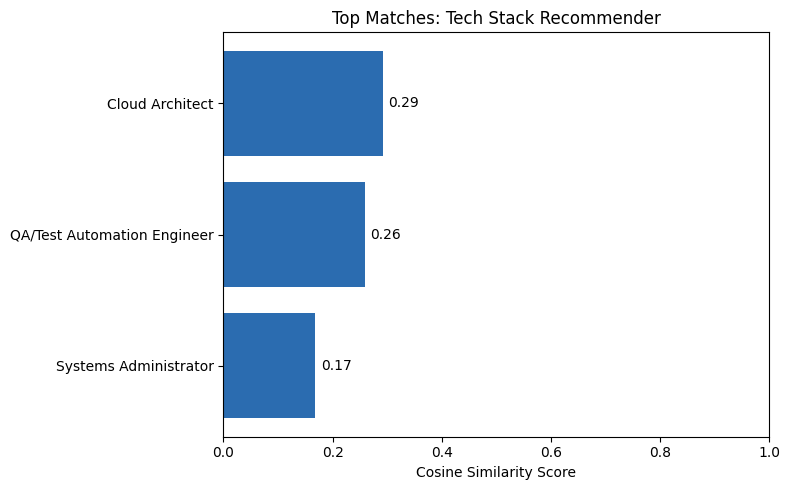

In [7]:
names = [df.iloc[i]["job_role"] for i in top_indices][::-1]
top_scores = [scores[i] for i in top_indices][::-1]

plt.figure(figsize=(8, 5))
bars = plt.barh(names, top_scores, color="#2b6cb0")
plt.xlabel("Cosine Similarity Score")
plt.title("Top Matches: Tech Stack Recommender")
plt.xlim(0, 1)
for bar, score in zip(bars, top_scores):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2, f"{score:.2f}", va="center")
plt.tight_layout()
plt.show()

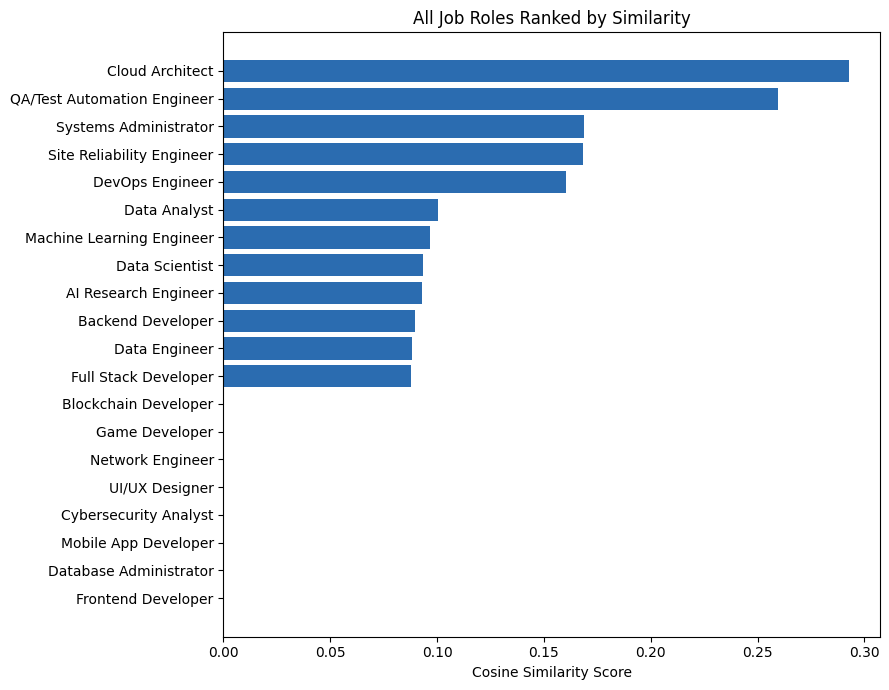

In [8]:
order = np.argsort(scores)[::-1]
all_names = df.iloc[order]["job_role"].tolist()
sorted_scores = scores[order]
colors = ["#2b6cb0" if s > 0 else "#cbd5e0" for s in sorted_scores]

plt.figure(figsize=(9, 7))
plt.barh(all_names[::-1], sorted_scores[::-1], color=colors[::-1])
plt.xlabel("Cosine Similarity Score")
plt.title("All Job Roles Ranked by Similarity")
plt.tight_layout()
plt.show()

## 6. Handling the Cold Start Problem
If a user's skills share zero vocabulary overlap with the dataset, every cosine
score is 0. Instead of returning an empty list, we fall back to a "Trending" list.

In [9]:
def trending_fallback(df, top_n=3):
    trending_order = ["Data Scientist", "Full Stack Developer", "DevOps Engineer",
                       "Cloud Architect", "Machine Learning Engineer"]
    fallback_roles = [r for r in trending_order if r in df["job_role"].values][:top_n]
    return df[df["job_role"].isin(fallback_roles)][["job_role", "description"]]

# Simulate a cold-start user with skills outside our vocabulary
cold_skills = normalize_skills(["zzz", "qqq", "wwq"])
cold_vector = vectorizer.transform([" ".join(cold_skills)])
cold_scores = cosine_similarity(cold_vector, item_matrix).flatten()

if np.allclose(cold_scores, 0.0):
    print("Cold start detected — falling back to trending roles:\n")
    print(trending_fallback(df))

Cold start detected — falling back to trending roles:

               job_role                                        description
0        Data Scientist  Analyzes data to extract insights and builds p...
1       DevOps Engineer  Manages infrastructure, deployment pipelines, ...
6  Full Stack Developer  Works across both frontend and backend of web ...


## 7. Conclusion
This notebook builds a full content-based recommendation engine: ingesting user
skills and a job-role dataset, mapping both into a shared TF-IDF vocabulary space,
scoring every item with Cosine Similarity, then sorting and filtering to a Top-N
list — with a graceful fallback for the Cold Start problem. This is the same
"Digital Matchmaker" logic that powers production recommendation engines like
Netflix and Amazon, applied here to career/tech-stack guidance.
